In [201]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [202]:
# Pointing the path to the import and parameter files
import sys
sys.path.insert(0, '../../')
# Import list
from imports import *
# Parameter list
import param_single_test as pm 

In [85]:
## rc parameter files

small = 12
medium = 16
big = 25

plt.rc('font', size=small)          # controls default text sizes
plt.rc('axes', titlesize=big)     # fontsize of the axes title
plt.rc('axes', labelsize=medium)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=small)    # fontsize of the tick labels
plt.rc('ytick', labelsize=small)    # fontsize of the tick labels
plt.rc('legend', fontsize=small)    # legend fontsize
plt.rc('figure', titlesize=big)  # fontsize of the figure title

In [159]:
## DATE, OBSERVATION NAME, FREQUENCY SLICES, FOLDER FOR SAVING
fname, dtime=tools.timepoint(fname=pm.file, date=None)
fs_slice=pm.fs_slice
fe_slice=pm.fe_slice
ts_slice=pm.ts_slice
te_slice=pm.te_slice


##FREQUENCY
print ('Frequeny range: '+str(fs_slice)+'-'+str(fe_slice)+' MHz')

##TIME
print ('Time range: '+str(ts_slice)+'-'+str(te_slice)+' seconds')

##MASK
if pm.mask==False:
    print ('Mask: No')
else:
    print ('Mask: Yes')
    print ('Degree masking: '+str(pm.degree))
    

##DAMPNER
print ('Dampner value: ',pm.dampner)
if pm.dampner!=None:
    print ('Dampner sigma level: '+str(pm.dampner_sigma))
    

Date of observation: 2019-02-25 02:40:11
Fname: 1551055211
Frequeny range: 1100-1350 MHz
Time range: 775-1000 seconds
Mask: No
Dampner value:  goob
Dampner sigma level: 5


### Satellite Catalogue

In [182]:
df = pd.read_csv(pm.satellite_catalogue) 

In [204]:
dff = df.loc[(df['Frequency[MHz]'] >= pm.fs_slice) & (df['Frequency[MHz]'] <= pm.fe_slice)]

dff_a = dff[dff['Sys'].str.contains('QZS-1') == False]

dff_as = dff_a[dff_a['Sys'].str.contains('IRNSS')]

In [205]:
dff_as

,Sys,Band,Signal,Frequency[MHz],Bandwidth,Modulation,Rate(MHz),P_t (dBW),G_t (dBi),Alpha
36,IRNSS,L5,SPS,1176.45,24.0,BPSK(1),1.023,16.0,14.0,1
37,IRNSS,L5,RS-D,1176.45,16.0,"BOC(5,2)",2.046,18.0,16.0,1


### Satellite fit

In [132]:
# check_off = np.where(dff_a['Signal']!='PRS(A)')[0]

In [207]:
s_alpha = [0, 1]

In [186]:
single_sat = pm.beam_model+'_SBAS1_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz'
multi_sat = pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz'

In [187]:
"""INITIALIZING THE SATELLITE FUNCTION"""
sat = ss(file_name=fname,          
             sats_only=None, 
             data_loc=pm.data_save, 
             sat_loc=pm.data_save,
             survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
             sat_info=pm.satellite_catalogue,
             plots_loc=pm.data_plot,
             sat_beam=single_sat, 
             frequency_range=[pm.fs, pm.fe], 
             constellations=pm.constellations_remain,
             nearby_satellites=pm.nearby_constellations,
             verbose=False)


time_slice = [pm.ts_slice, pm.te_slice]
frequency_slice = [pm.fs_slice, pm.fe_slice]

In [188]:
st_path = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_2/'
stf_name = 'full_no_mask_satellite_f_1000_1500MHz__1100_1350MHz_'+str(time_slice[0])+'_'+str(time_slice[1])+'_sec_v2.p'

dic_vals = pickle.load(open(st_path+stf_name, 'rb'))
print ('Time: '+str(time_slice[0])+'-'+str(time_slice[1])+' - '+str(dic_vals['chi2_value'])+' - '+str(dic_vals['chi2_div']))
time_alpha = dic_vals['best-fit']

Time: 775-1000 - 57068.549596660305 - 0.5534510308654529


In [189]:
alpha=s_alpha 
dampner=None
dampner_sig=1*np.ones(len(pd.read_csv(pm.satellite_catalogue)))


sat.excecute(a_param=alpha, 
             obs_time_start=time_slice[0], obs_time_end=time_slice[1], 
             obs_frequency_start=frequency_slice[0], obs_frequency_end=frequency_slice[1], 
             file_bias_choice=pm.bias, 
             add_sub=[1, 1], 
             band_lvl=[dampner, dampner_sig], 
             bandsize=None,
             verbose=True)

Number of signals inside choice frequency range:  1


In [190]:
def satellite_exc(alpha, dampner=None, dampner_sig=None):
    """EXCECUTING THE THE SATELLITE SIM FUNCTION"""
    sat.excecute(a_param=alpha, 
                 obs_time_start=time_slice[0], obs_time_end=time_slice[1], 
                 obs_frequency_start=frequency_slice[0], obs_frequency_end=frequency_slice[1], 
                 file_bias_choice=pm.bias, 
                 add_sub=[1, 1], 
                 band_lvl=[dampner, dampner_sig], 
                 bandsize=None,
                 verbose=True)
    
    fslice=sat.frequency_band[sat.frequency_idx[0]:sat.frequency_idx[1]]
    sed = sat.satellite_SED[:, sat.frequency_idx[0]:sat.frequency_idx[1]]
    
    return sat.calibration_data_slice, sat.simulation_TOD_slice, fslice, sed

In [191]:
cdata, csim, fslice, csed = satellite_exc(alpha=s_alpha, dampner='goob', dampner_sig=5*np.ones(len(pd.read_csv(pm.satellite_catalogue))))



Number of signals inside choice frequency range:  1


In [140]:
# fig, axs = plt.subplots(figsize=(16, 8), nrows=2, ncols=1)
# fig.suptitle('Single GALILEO Stallite for One Signal')

# ax=axs[0]
# ax.plot(fslice, np.mean(cdata, axis=1), label='Data')
# ax.plot(fslice, np.mean(csim, axis=1), alpha=0.5, label=r'1xGAL: E6-PRS(A); Dampner $\sigma$=5')
# # ax.plot(fslice, np.mean(csim, axis=1), alpha=0.5, label=r'1xGAL: E6-PRS(A); Dampner: None')

# ax.axvline(1278.750, color='r', linestyle='--', label=r'$v_{0}$=1278.75 MHz')
# ax.axvspan(1278.750-7.5, 1278.750+7.5, alpha=0.2, color='red', label='Bandwidth: 15 MHz')

# ax.set_xlim(1250, 1320)
# ax.set_ylabel('Temperature [K]')
# ax.set_xlabel('Frequency [MHz]')
# ax.legend()

# ax=axs[1]
# ax.plot(fslice, np.mean((cdata - csim)/cdata, axis=1), color='m', label='Fractional residual')
# ax.set_ylabel(r'$\dfrac{D_T - S_T}{D_T}$')
# ax.set_xlabel('Frequency [MHz]')
# ax.axvline(1278.750, color='r', linestyle='--', label=r'$v_{0}$=1278.75 MHz')
# ax.axvspan(1278.750-7.5, 1278.750+7.5, alpha=0.2, color='red')
# ax.legend()
# ax.set_xlim(1250, 1320)


# fig.tight_layout()
# plt.show()


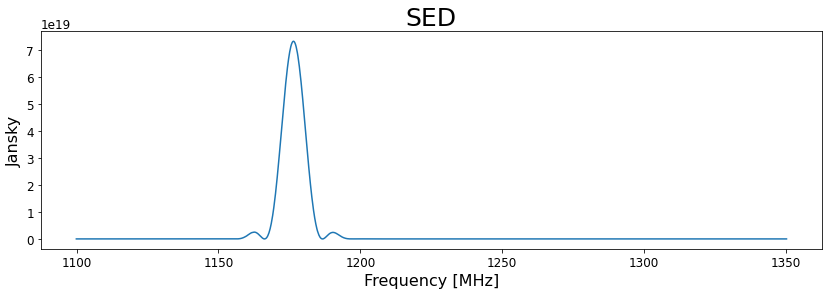

In [192]:
plt.figure(figsize=(14, 4))
plt.plot(fslice, csed[0])

# plt.xlim(1250, 1310)

plt.title('SED')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Jansky')
plt.show()

#### Attenuation applied from the code to the sed

In [208]:
bw = 32/2
sigma=10
fi=1176.45	
goob_sed = af.gaussian_oob(f=fslice, fi=fi, band=bw, sigma=sigma, values=csed[0])

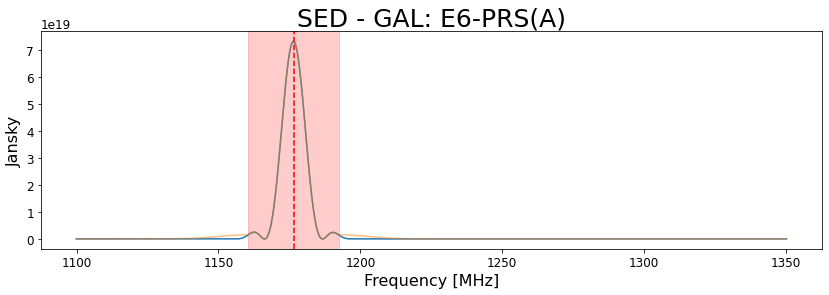

In [209]:
fig, axs = plt.subplots(figsize=(14, 4))
ax=axs
ax.plot(fslice, csed[0])
ax.plot(fslice, goob_sed, alpha=0.5)

ax.axvline(fi, color='r', linestyle='--', label=r'$v_{0}$=1278.75 MHz')
ax.axvspan(fi-bw, fi+bw, alpha=0.2, color='red')

# ax.set_xlim(1250, 1310)


ax.set_title('SED - GAL: E6-PRS(A)')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Jansky')
plt.show()

#### Attenuation applied manually

In [210]:
sig_val = [1, 3, 10]
goob = []
for i in sig_val:

    goob.append( af.gaussian_oob(f=fslice, fi=fi, band=bw, sigma=i, values=np.ones(len(csed[0]))))






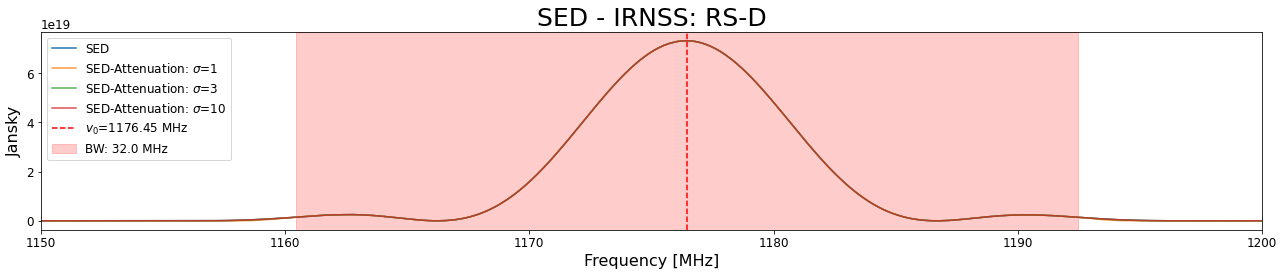

In [220]:
fig, axs = plt.subplots(figsize=(18, 4))
ax=axs
ax.plot(fslice, csed[0], label='SED')
# ax.plot(fslice, goob_sed, alpha=0.5, label=r'SED-Attenuation: Old $\sigma$='+str(sigma))

for i, si in enumerate(sig_val):
    ax.plot(fslice, goob[i] * csed[0], alpha=0.8, label=r'SED-Attenuation: $\sigma$='+str(si))

ax.axvline(fi, color='r', linestyle='--', label=r'$v_{0}$='+str(fi)+' MHz')
ax.axvspan(fi-bw, fi+bw, alpha=0.2, color='red', label='BW: '+str(bw*2)+' MHz')

ax.set_xlim(1150, 1200)
# ax.set_ylim(0, 0.5e19)

ax.legend()

ax.set_title('SED - IRNSS: RS-D')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Jansky')

fig.tight_layout()
# plt.savefig('/users/bengelbrecht/hi_im/brandon/thesis_plots/SED/IRNSS-RS-D.pdf')
plt.show()